In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *
from compressibleSPH.modules.timestep.compressible import computeTimestep

# The case utilities that contain all the case setup functions for the various test cases
from compressibleSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [16]:
nx = 128
dim = 2
L = 2
n_h = 4

gamma = 5/3
rho0 = 1


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
}

In [17]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = WeaklyCompressibleSPHScheme.deltaSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False


In [18]:
compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)

In [19]:
k = 2
u_mag = 1
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * compressibleSystem.state.positions[:,1] + phaseShift_y)


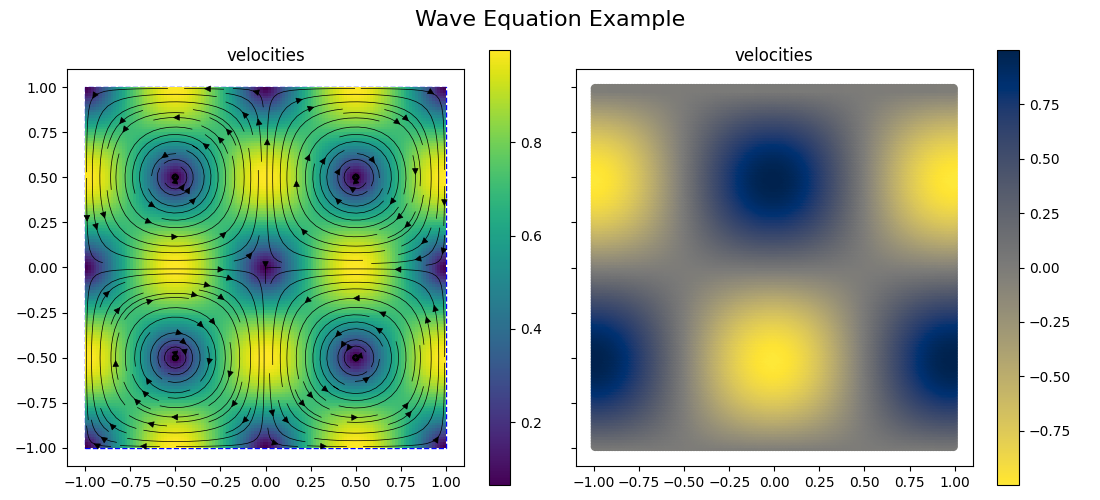

In [20]:
runningState = compressibleSystem.initializeNewState()

from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 32
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 128,
                streamLines = True
            ),
            # # vMin=1e-10,
            # stream
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.y,
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)


# imagePath = f'{exportPath}/images'
# os.makedirs(imagePath, exist_ok = True)
# plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)

In [21]:
# Delta SPH Loop:
# 1. Compute adjacency
# 2. Compute density if density is none
# 3. Compute mDBC density (only if boundaries)
# 4. enforce BCs
# 5. compute EOS (WC version)
# 6. Compute boundary velocities (only if boundaries)
# 7. Compute Covariance Matrices for gradRho_l terms
# 8. Run surface detection (only if free surface)
# 9. Compute gradRho and gradRhoL
# 10. Compute drhodt_diss
# 11. Compute dvdt_diss
# 12. Compute drhodt
# 13. Compute dvdt from pressure
# 14. Apply forcing
# 15. build update
# 16. Enforce BCs on update
# 17. If finalize, compute shifting and update positions and velocities

In [22]:
system = compressibleSystem.initializeNewState()
print(system.state.densities)

tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0')


In [23]:
from compressibleSPH.configurations import *
from sphWarpCore.enumTypes import ViscosityTerms


def deltaSPH_step(
    system: CompSPHSystem,
    dt: float,
    config: SimulationConfig,
    schemeConfig: WeaklyCompressibleSPHConfig,
    verbose = False,        
):
    currentSystem = system#
    currentState = currentSystem.state
    adjacency = currentSystem.adjacency

    # 1. Compute adjacency
    verletScale = config.verletScale

    adjacency = buildVerletList(
        currentState, 
        config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    currentSystem.adjacency = adjacency

    # 2. Compute density if density is none
    if currentState.densities is None:
        currentState.densities = warpOperation(
            currentState,
            OperationProperties(
                kernel = config.kernel,
                operation = WarpOperation.Density,
                supportMode = SupportScheme.Gather, # cullen switch E.1 in the CRK paper uses gather for density estimation
            ),
            domain = config.domain,
            adjacency = adjacency,
        )
    # 3. Skipped mDBC density computation since no boundaries are present
    # 4. enforce BCs
    enforceDirichlet(currentSystem, currentSystem.t, config.dt, config, schemeConfig)
    # 5. compute EOS (WC version)
    currentState.pressures = weaklyCompressibleEOS(currentState, schemeConfig)
    # 6. Skipped boundary velocity computation since no boundaries are present
    # 7. Compute Covariance Matrices for gradRho_l terms
    C, Evals, L = computeRenormalizationMatrices(
        queryParticles = currentState,
        operationProperties = OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Gradient,
            operationMode = OperationDirection.AllToAll,
            supportMode = SupportScheme.SuperSymmetric
        ),
        domain = config.domain,
        adjacency = adjacency,
        returnEigVals = True
    )
    # # For testing purposes set L to be a 90 degree rotation matrix in 2D
    # L.renormalizationMatrices[:,0,0] = 0
    # L.renormalizationMatrices[:,0,1] = -1
    # L.renormalizationMatrices[:,1,0] = 1
    # L.renormalizationMatrices[:,1,1] = 0
    # testQuantity = torch.sin(2 * np.pi * currentState.positions[:,0])


    # markerSize = 4
    # fig, axis = plt.subplots(2, 2, figsize=(11, 10), squeeze=False)

    # sc = axis[0,0].scatter(currentState.positions[:,0].cpu(), currentState.positions[:,1].cpu(), c=gradRho[:,0].cpu(), s=markerSize, cmap='RdBu_r')
    # fig.colorbar(sc, ax=axis[0,0])
    # sc = axis[0,1].scatter(currentState.positions[:,0].cpu(), currentState.positions[:,1].cpu(), c=gradRho[:,1].cpu(), s=markerSize, cmap='RdBu_r')
    # fig.colorbar(sc, ax=axis[0,1])
    # sc = axis[1,0].scatter(currentState.positions[:,0].cpu(), currentState.positions[:,1].cpu(), c=gradRhoL[:,0].cpu(), s=markerSize, cmap='RdBu_r')
    # fig.colorbar(sc, ax=axis[1,0])
    # sc = axis[1,1].scatter(currentState.positions[:,0].cpu(), currentState.positions[:,1].cpu(), c=gradRhoL[:,1].cpu(), s=markerSize, cmap='RdBu_r')
    # fig.colorbar(sc, ax=axis[1,1])

    # axis[0,0].set_title("gradRho x-component")
    # axis[0,1].set_title("gradRho y-component")
    # axis[1,0].set_title("gradRhoL x-component")
    # axis[1,1].set_title("gradRhoL y-component")

    # for ax in axis.flatten():
    #     ax.set_aspect('equal', 'box')
    #     ax.set_xlim(config.domain.min[0].cpu(), config.domain.max[0].cpu())
    #     ax.set_ylim(config.domain.min[1].cpu(), config.domain.max[1].cpu())

    # fig.tight_layout()
    # 8. Run surface detection (only if free surface)
    #9. Compute gradRho and gradRhoL
    gradRho = warpOperation(
        currentState,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Gradient,
            supportMode = SupportScheme.SuperSymmetric,
            operationMode = OperationDirection.AllToAll,
            gradientMode = GradientScheme.Naive
        ),
        queryValues = currentState.densities,
        # queryValues = testQuantity,
        domain = config.domain,
        adjacency = adjacency,
        # renormalizationState = RenormalizationState(C=C, eigVals=Evals, L=L)
    )

    gradRhoL = warpOperation(
        currentState,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Gradient,
            supportMode = SupportScheme.SuperSymmetric,
            operationMode = OperationDirection.AllToAll,
            gradientMode = GradientScheme.Difference
        ),
        queryValues = currentState.densities,
        # queryValues = testQuantity,
        domain = config.domain,
        adjacency = adjacency,
        renormalizationState = L
    )


    # 10. Compute drhodt_diss
    drhodt_diss = computeDensityDiffusionDeltaSPH(
        currentState,
        operationProperties = OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Divergence,
            supportMode = SupportScheme.SuperSymmetric,
            operationMode = OperationDirection.AllToAll,
        ),
        domain = config.domain,
        adjacency = adjacency,
        queryGradRho = gradRho,
        queryGradRhoL = gradRhoL,
        densityScheme = schemeConfig.densityDiffusionTerm
    )

    # 11. Compute dvdt_diss
    schemeConfig.diffusionParams.C_l = 0.01 # alpha parameter for delta-SPH
    schemeConfig.diffusionParams.C_q = 0.0
    schemeConfig.diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value

    dvdt_diss = computeViscosity(
        currentState,
        # queryVelocities=currentState.velocities,
        operationProperties = OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.SuperSymmetric,
        ),
        domain = config.domain,
        adjacency = adjacency,
        viscosityParams = schemeConfig.diffusionParams,
    )

    # 12. Compute drhodt
    drhodt = warpOperation(
        currentState,
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Divergence,
            supportMode = SupportScheme.SuperSymmetric,
            operationMode = OperationDirection.AllToAll,
            gradientMode = GradientScheme.Difference
        ),
        queryValues = currentState.velocities,
        domain = config.domain,
        adjacency = adjacency,
        consistentDivergence = False
    )

    # 13. Compute dvdt from pressure
    dvdt = computePressureForceSurfaceAware(
        currentState,
        operationProperties = OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.SuperSymmetric,
        ),
        domain = config.domain,
        adjacency = adjacency,
        queryPressures = currentState.pressures,
        pressureTerm = schemeConfig.pressureForceTerm
    )

    # 14. Apply forcing
    forcing = computeForcing(currentSystem, config.dt, currentSystem.t, config, schemeConfig)
    dvdt += forcing / currentState.masses.view(-1,1)

    # 15. build update
    update = WeaklyCompressibleSystemUpdate(
        dxdt = currentState.velocities.clone(),
        dvdt = dvdt,
        drhodt = drhodt,
        passive = torch.zeros(currentState.densities.shape, device=currentState.densities.device, dtype=torch.bool)
    )

    # 16. Enforce BCs on update
    enforceUpdates(update, currentSystem, config.dt, currentSystem.t, config, schemeConfig)

    return update, adjacency, currentState

In [24]:
runningState = compressibleSystem.initializeNewState()
from compressibleSPH.modules.timestep.weaklyCompressible import computeTimestep

config.dt = computeTimestep(
    system = compressibleSystem,
    config = config,
    compParams = schemeConfig,
    dt = 1e-4,
    systemUpdate = None,
)
print(config.dt)

tensor(0.0005, device='cuda:0')


In [25]:
runningState.state.densities

tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0')

In [26]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 16
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [ ]:
# config.dt = 2.5e-4
t_limit = 1.0
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 256

runningState = compressibleSystem.initializeNewState()

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = deltaSPH_step,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if i % 60 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 0.0004767674836330116, which gives nSteps: 2097


  0%|          | 0/2097 [00:00<?, ?it/s]

In [ ]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': i,
}))

In [ ]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');